In [1]:
from sklearn.manifold import TSNE
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# np.random.randint(10, 150, 10)

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_dims = 16
n_clusters = 10
# this generated imbalanced clusters
n_samples_per_cluster = np.random.randint(10, 150, 10)
# n_total_samples = n_clusters * n_samples_per_cluster
n_total_samples = np.sum(n_samples_per_cluster)

print("=" * 60)
print("Generating 10 overlapping clusters in 16D space")
print("=" * 60)

# Generate 10 overlapping clusters
cluster_centers = np.random.randn(n_clusters, n_dims) * 5
true_labels = np.repeat(np.arange(n_clusters), n_samples_per_cluster)

# Generate points with some overlap (larger std deviation creates more overlap)
X = np.zeros((n_total_samples, n_dims))
start_idx = 0
for i in range(n_clusters):
    print(n_samples_per_cluster[i])
    # start_idx = i * n_samples_per_cluster[i]
    end_idx = start_idx + n_samples_per_cluster[i]
    # Add noise with relatively large std to create overlap
    X[start_idx:end_idx] = cluster_centers[i] + np.random.randn(int(n_samples_per_cluster[i]), n_dims) * 4.0
    start_idx = end_idx

print(f"Generated {n_total_samples} points in {n_dims}D space")
print(f"True labels: {n_clusters} clusters\n")

Generating 10 overlapping clusters in 16D space
112
102
24
116
81
30
112
131
84
97
Generated 889 points in 16D space
True labels: 10 clusters



In [11]:
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X)

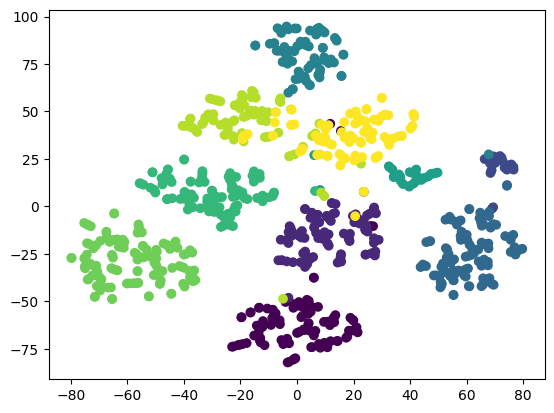

In [12]:
# check that generated data is not a complete mess
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=true_labels)

Creating 3 non-orthogonal coordinate bases

Basis 1:
  Rank: 16 (should be 16)
  Average absolute dot product between axes: 3.4102
  (Note: 0 = orthogonal, >0 = non-orthogonal)

Basis 2:
  Rank: 16 (should be 16)
  Average absolute dot product between axes: 3.3261
  (Note: 0 = orthogonal, >0 = non-orthogonal)

Basis 3:
  Rank: 16 (should be 16)
  Average absolute dot product between axes: 2.9400
  (Note: 0 = orthogonal, >0 = non-orthogonal)

Projecting data into each coordinate basis

Projection 1 shape: (889, 16)

Projection 2 shape: (889, 16)

Projection 3 shape: (889, 16)

Running K-Means clustering on each projection

Projection 1 clustering complete
  Unique labels: 10

Projection 2 clustering complete
  Unique labels: 10

Projection 3 clustering complete
  Unique labels: 10

Computing Adjusted Rand Index (ARI) between clusterings

ARI Matrix (between projection clusterings):
Projection 1: 1.0000  0.5819  0.5375  
Projection 2: 0.5819  1.0000  0.6185  
Projection 3: 0.5375  0.6185

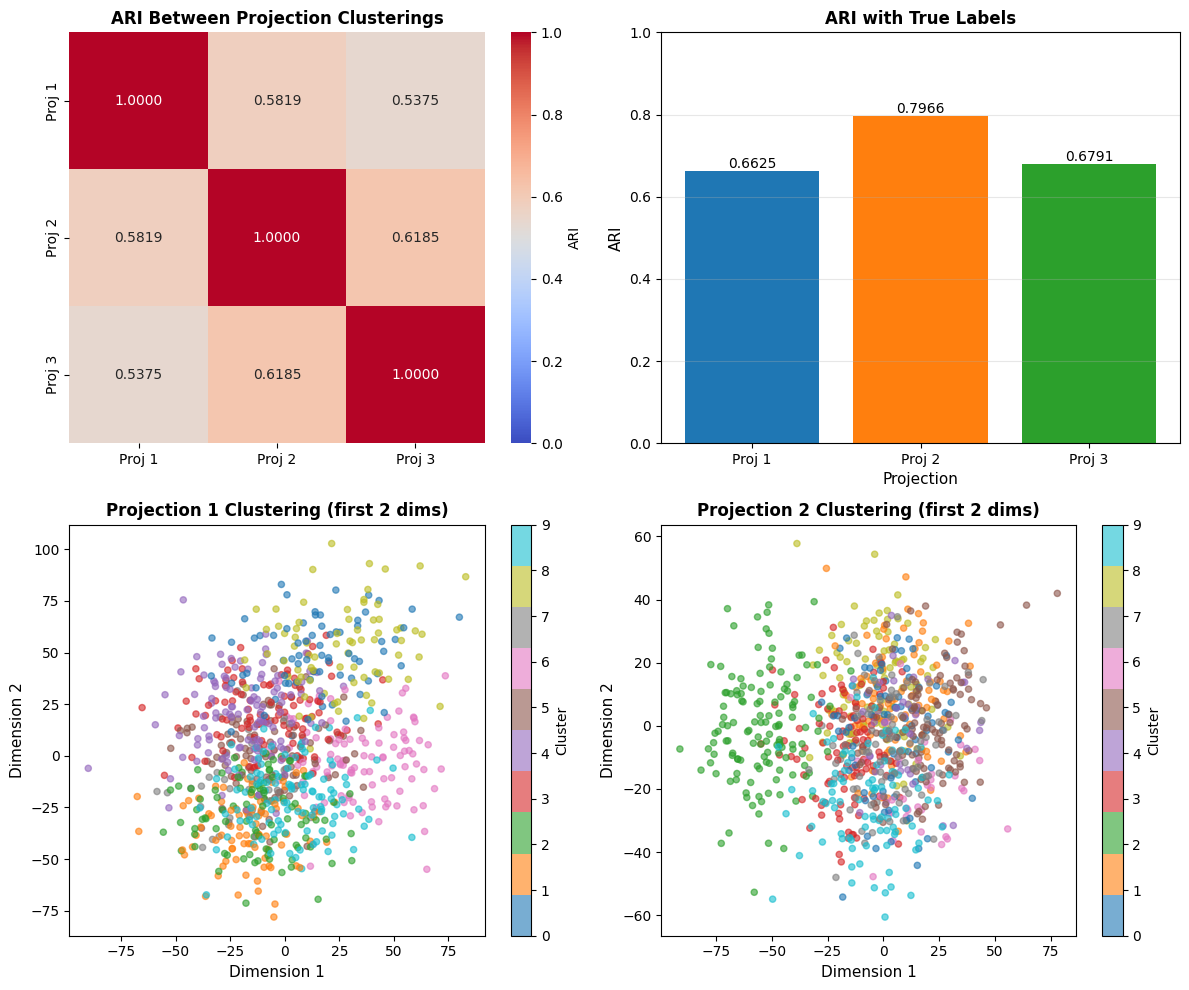

In [50]:
# Create 3 non-orthogonal coordinate bases
print("=" * 60)
print("Creating 3 non-orthogonal coordinate bases")
print("=" * 60)

# def create_non_orthogonal_basis(n_dims, seed):
#     """
#     Create a non-orthogonal basis where axes are independent but not orthogonal.
#     We create a basis by generating random vectors and ensuring they're linearly independent.
#     """
#     np.random.seed(seed)

#     # Start with random vectors
#     basis = np.random.randn(n_dims, n_dims)

#     # Make them non-orthogonal by adding correlations
#     # We'll add some of each vector to others
#     for i in range(n_dims):
#         if i < n_dims - 1:
#             basis[i] += 0.5 * basis[i + 1]

#     # Ensure linear independence by checking rank
#     if np.linalg.matrix_rank(basis) < n_dims:
#         print(f"Warning: Basis {seed} is not full rank, regenerating...")
#         return create_non_orthogonal_basis(n_dims, seed + 1000)

#     return basis

def create_non_orthogonal_basis_v2(n_dims, seed, dependence=0.9):
    np.random.seed(seed)

    # Start with orthogonal basis (from QR decomposition)
    Q, _ = np.linalg.qr(np.random.randn(n_dims, n_dims))

    # Make it non-orthogonal by linear combinations
    basis = Q.copy()
    for i in range(1, n_dims):
        # Add a fraction of the first vector to all others
        basis[i] = basis[i] + dependence * basis[0]
    basis = np.random.randn(n_dims, n_dims)
    # Ensure linear independence by checking rank
    if np.linalg.matrix_rank(basis) < n_dims:
        print(f"Warning: Basis {seed} is not full rank, regenerating...")
        return create_non_orthogonal_basis(n_dims, seed + 1000)

    return basis

# Create 3 different bases
bases = []
for i in range(3):
    # basis = create_non_orthogonal_basis(n_dims, seed=100 + i * 50)
    basis = create_non_orthogonal_basis_v2(n_dims, seed=100 + i * 50)
    bases.append(basis)

    # Check orthogonality
    dot_products = []
    for j in range(n_dims):
        for k in range(j + 1, n_dims):
            dot_prod = np.dot(basis[j], basis[k])
            dot_products.append(abs(dot_prod))

    avg_dot_product = np.mean(dot_products)
    print(f"\nBasis {i + 1}:")
    print(f"  Rank: {np.linalg.matrix_rank(basis)} (should be {n_dims})")
    print(f"  Average absolute dot product between axes: {avg_dot_product:.4f}")
    print(f"  (Note: 0 = orthogonal, >0 = non-orthogonal)")

print("\n" + "=" * 60)
print("Projecting data into each coordinate basis")
print("=" * 60)

# Project data into each basis
projections = []
for i, basis in enumerate(bases):
    # Project: X_projected = X @ basis.T
    X_proj = X @ basis.T
    projections.append(X_proj)
    print(f"\nProjection {i + 1} shape: {X_proj.shape}")

print("\n" + "=" * 60)
print("Running K-Means clustering on each projection")
print("=" * 60)

# Run K-Means clustering on each projection
clusterings = []
for i, X_proj in enumerate(projections):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_proj)
    clusterings.append(labels)
    print(f"\nProjection {i + 1} clustering complete")
    print(f"  Unique labels: {len(np.unique(labels))}")

print("\n" + "=" * 60)
print("Computing Adjusted Rand Index (ARI) between clusterings")
print("=" * 60)

# Compute ARI between all pairs of projections
ari_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        ari = adjusted_rand_score(clusterings[i], clusterings[j])
        ari_matrix[i, j] = ari

print("\nARI Matrix (between projection clusterings):")
print("=" * 40)
for i in range(3):
    row_str = f"Projection {i + 1}: "
    for j in range(3):
        row_str += f"{ari_matrix[i, j]:6.4f}  "
    print(row_str)

print("\n" + "=" * 60)
print("ARI with true labels:")
print("=" * 60)
for i in range(3):
    ari_true = adjusted_rand_score(true_labels, clusterings[i])
    print(f"Projection {i + 1} vs True labels: {ari_true:.4f}")

# Create visualization
print("\n" + "=" * 60)
print("Creating visualization...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: ARI heatmap between projections
ax = axes[0, 0]
sns.heatmap(ari_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            xticklabels=[f'Proj {i+1}' for i in range(3)],
            yticklabels=[f'Proj {i+1}' for i in range(3)],
            vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'ARI'})
ax.set_title('ARI Between Projection Clusterings', fontsize=12, fontweight='bold')

# Plot 2: ARI with true labels
ax = axes[0, 1]
ari_true_scores = [adjusted_rand_score(true_labels, clusterings[i]) for i in range(3)]
bars = ax.bar(range(3), ari_true_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_xlabel('Projection', fontsize=11)
ax.set_ylabel('ARI', fontsize=11)
ax.set_title('ARI with True Labels', fontsize=12, fontweight='bold')
ax.set_xticks(range(3))
ax.set_xticklabels([f'Proj {i+1}' for i in range(3)])
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{ari_true_scores[i]:.4f}',
            ha='center', va='bottom', fontsize=10)

# Plot 3: 2D projection of first projection (first 2 dims)
ax = axes[1, 0]
scatter = ax.scatter(projections[0][:, 0], projections[0][:, 1],
                     c=clusterings[0], cmap='tab10', s=20, alpha=0.6)
ax.set_xlabel('Dimension 1', fontsize=11)
ax.set_ylabel('Dimension 2', fontsize=11)
ax.set_title('Projection 1 Clustering (first 2 dims)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')

# Plot 4: 2D projection of second projection (first 2 dims)
ax = axes[1, 1]
scatter = ax.scatter(projections[1][:, 0], projections[1][:, 1],
                     c=clusterings[1], cmap='tab10', s=20, alpha=0.6)
ax.set_xlabel('Dimension 1', fontsize=11)
ax.set_ylabel('Dimension 2', fontsize=11)
ax.set_title('Projection 2 Clustering (first 2 dims)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/clustering_analysis.png', dpi=300, bbox_inches='tight')
print("Saved visualization to clustering_analysis.png")

# Additional analysis: pairwise ARI comparisons
print("\n" + "=" * 60)
print("Pairwise ARI Comparisons:")
print("=" * 60)
pairs = [(0, 1), (0, 2), (1, 2)]
pair_names = [("Proj 1", "Proj 2"), ("Proj 1", "Proj 3"), ("Proj 2", "Proj 3")]
for (i, j), (name_i, name_j) in zip(pairs, pair_names):
    ari = ari_matrix[i, j]
    print(f"{name_i} vs {name_j}: ARI = {ari:.4f}")

print("\n" + "=" * 60)
print("Summary Statistics:")
print("=" * 60)
off_diagonal = [ari_matrix[i, j] for i in range(3) for j in range(3) if i != j]
print(f"Mean ARI between different projections: {np.mean(off_diagonal):.4f}")
print(f"Std ARI between different projections: {np.std(off_diagonal):.4f}")
print(f"Min ARI between different projections: {np.min(off_diagonal):.4f}")
print(f"Max ARI between different projections: {np.max(off_diagonal):.4f}")

print("\n" + "=" * 60)
print("Analysis complete!")
print("=" * 60)

In [51]:
n = 100
labels = []
for seed in range(n):
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    labels.append(kmeans.fit_predict(X))

aris = []
for i in range(n):
    for j in range(i):
        aris.append(adjusted_rand_score(labels[i], labels[j]))

print(f'Mean ARI on original data (same coordinate frame) with different clustering seeds {np.mean(aris)}')

Mean ARI on original data (same coordinate frame) with different clustering seeds 0.9311666646581244


In [52]:
X

array([[-1.16154084, -0.17411324, -3.55505119, ...,  7.33375429,
         5.25039696, -1.16043401],
       [-8.26573026,  2.35877047,  0.1238672 , ..., 12.12302041,
        -1.61475265,  3.79214484],
       [ 6.70960046, -2.1856896 , -2.45942726, ...,  4.1808204 ,
        -9.39454888,  0.70568318],
       ...,
       [ 7.46234673,  0.98320557,  1.75139877, ..., -1.20078019,
        -2.01204593, -8.64525757],
       [-3.86889397,  2.18336649,  0.96957295, ...,  4.12618953,
        -3.06720171, -3.71627664],
       [ 1.53540401,  0.54570944,  3.00384523, ..., -1.38164868,
        -2.37032469, -4.15572851]], shape=(889, 16))

### Now check spectrums of the created basises

In [53]:
len(projections), len(bases )

(3, 3)

In [54]:
bases[0].shape

(16, 16)

In [55]:
np.eye(16).shape

(16, 16)

In [79]:
def get_eigenvalues(Xc):
  Xc = Xc - Xc.mean(axis=0)
  # SVD returns U, S, Vh. We only need S (singular values)
  # Using 'reduced' SVD is memory efficient
  _, S, _ = np.linalg.svd(Xc, full_matrices=False)

  # Convert singular values to eigenvalues of the covariance matrix
  eigvals = (S**2) / (Xc.shape[0] - 1)
  return eigvals

Text(0.5, 0, 'eignevalue number')

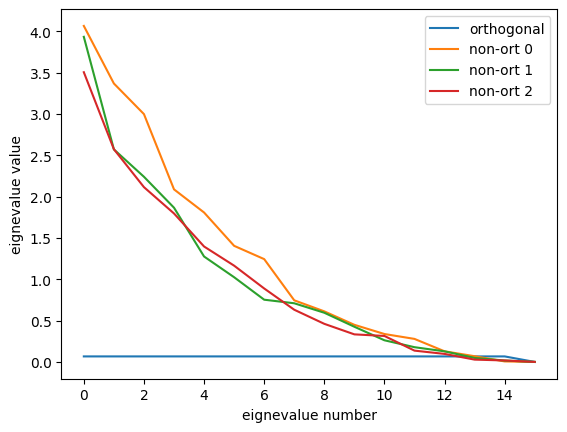

In [82]:
plt.plot(get_eigenvalues(np.eye(16)), label='orthogonal')
for i, b in enumerate(bases):
  plt.plot(get_eigenvalues(b), label=f'non-ort {i}')
#plt.yscale('log')
plt.legend()
plt.ylabel('eignevalue value')
plt.xlabel('eignevalue number')
#

In [57]:
print(get_eigenvalues(np.eye(16)))

[0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.06666667]


In [58]:
for i, b in enumerate(bases):
  print(get_eigenvalues(b))
  print()

[0.93859814 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.00473519]

[0.93859814 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.00473519]

[0.93859814 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.00473519]



Text(0.5, 0, 'eignevalue number')

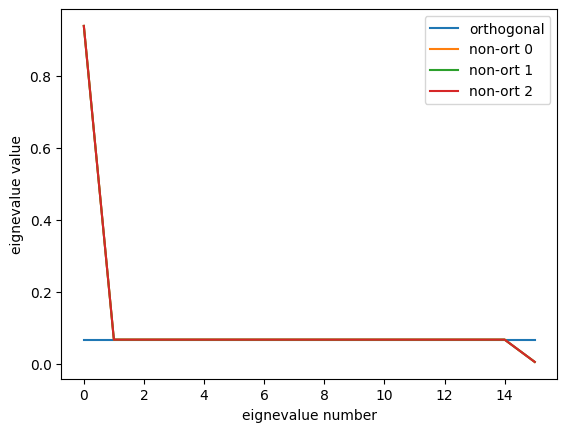

In [59]:
plt.plot(get_eigenvalues(np.eye(16)), label='orthogonal')
for i, b in enumerate(bases):
  plt.plot(get_eigenvalues(b), label=f'non-ort {i}')
# plt.yscale('log')
plt.legend()
plt.ylabel('eignevalue value')
plt.xlabel('eignevalue number')

In [83]:
def plot_recon(n, d=2, mu=None, cov=None, fig_path=None):
    mu = np.zeros(d) if mu is None else mu
    cov = np.eye(d) if cov is None else cov

    d = len(mu)
    mu = np.array(mu)
    cov = np.array(cov)

    X = np.random.multivariate_normal(mu, cov, n).T  # data
    B = np.random.randn(d, d)  # basis

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))

    for i in range(d):
        axs[0].plot([0, B[0, i]], [0, B[1, i]], label=f'vec {i + 1}', lw=4)

    axs[0].scatter(X[0], X[1], c='g')
    axs[0].axis('equal')
    axs[0].set_xlabel('x')
    axs[0].set_ylabel('y')
    axs[0].legend(title='basis')
    
    # transform basis
    Binv = np.linalg.inv(B)
    BinvX = Binv @ X

    axs[1].scatter(BinvX[0], BinvX[1])
    axs[1].axis('equal')
    axs[1].set_xlabel('basis vec 1')
    axs[1].set_ylabel('basis vec 2')

    # compute inverse covarience
    BinvXc = BinvX - BinvX.mean(axis=1, keepdims=True)
    cov = BinvXc @ BinvXc.T / (n - 1)
    covInv = np.linalg.inv(cov)
    BTB = B.T @ B 

    print('Cov inv')
    print(covInv)
    print('B^T B')
    print(BTB)

    # eigen decomp of inverse cov to get original basis
    lam, U = np.linalg.eigh(covInv)
    B_rec = np.eye(d) * lam ** 0.5 @ U.T

    # reconstruct data
    X_rec = B_rec @ BinvX

    for i in range(d):
        axs[2].plot([0, B_rec[0, i]], [0, B_rec[1, i]], label=f'vec {i + 1}', lw=4)
    axs[2].scatter(X_rec[0], X_rec[1], c='g')
    axs[2].axis('equal')
    axs[2].set_xlabel('x rec')
    axs[2].set_ylabel('y rec')
    axs[2].legend(title='reconstructed basis')

    # compute differece between dists
    original_dists = ((X[:, None, :] - X[:, :, None]) ** 2).sum(axis=0) ** 0.5
    recon_dists = ((X_rec[:, None, :] - X_rec[:, :, None]) ** 2).sum(axis=0) ** 0.5

    i, j = np.tril_indices(n, k=-1)
    abs_diff = np.abs(original_dists[i, j] - recon_dists[i, j])

    axs[3].hist(abs_diff)
    axs[3].set_xlabel('absotule distance difference')
    axs[3].set_ylabel('count')

    plt.tight_layout()
    if fig_path:
        plt.savefig(fig_path)
    plt.show()

Cov inv
[[10.86209872  3.76172132]
 [ 3.76172132  4.66607344]]
B^T B
[[11.11558223  3.63763865]
 [ 3.63763865  4.61564241]]


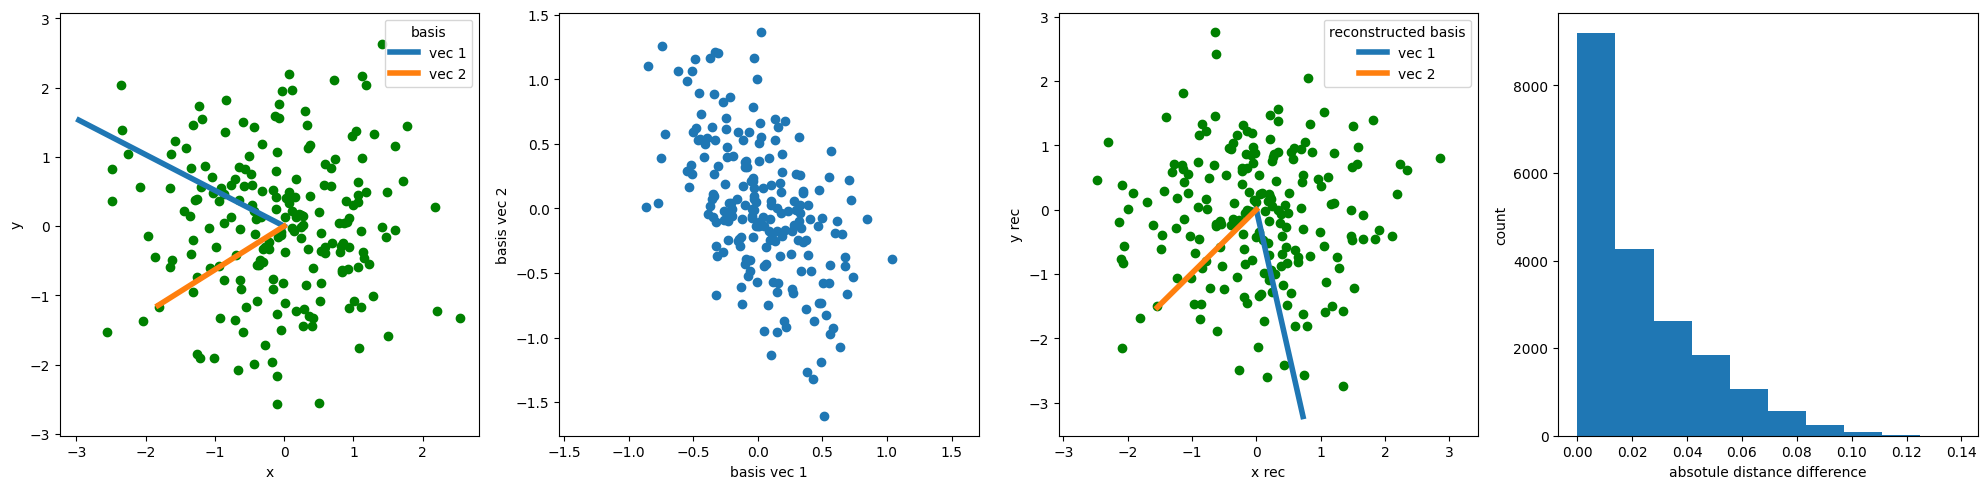

In [81]:
plot_recon(200, fig_path='plots/basis_recon_normal.png')

Cov inv
[[1.73801836 0.57103226]
 [0.57103226 1.19949094]]
B^T B
[[1.48766018 0.39188095]
 [0.39188095 1.09933702]]


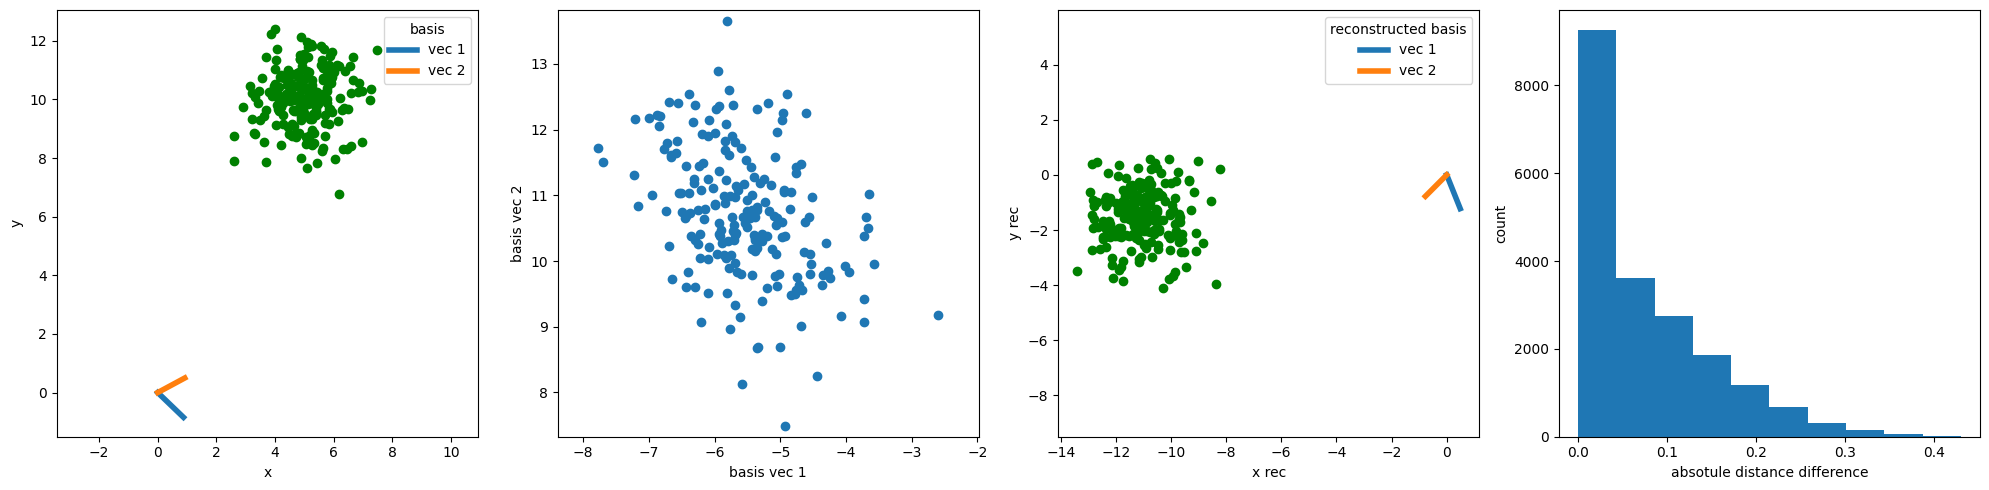

In [75]:
mu = [5, 10]
plot_recon(200, mu=mu, fig_path='plots/basis_recon_shift.png')

Cov inv
[[ 0.63119104 -0.62875119]
 [-0.62875119  1.02725251]]
B^T B
[[ 0.1798985  -0.35111786]
 [-0.35111786  2.11909808]]


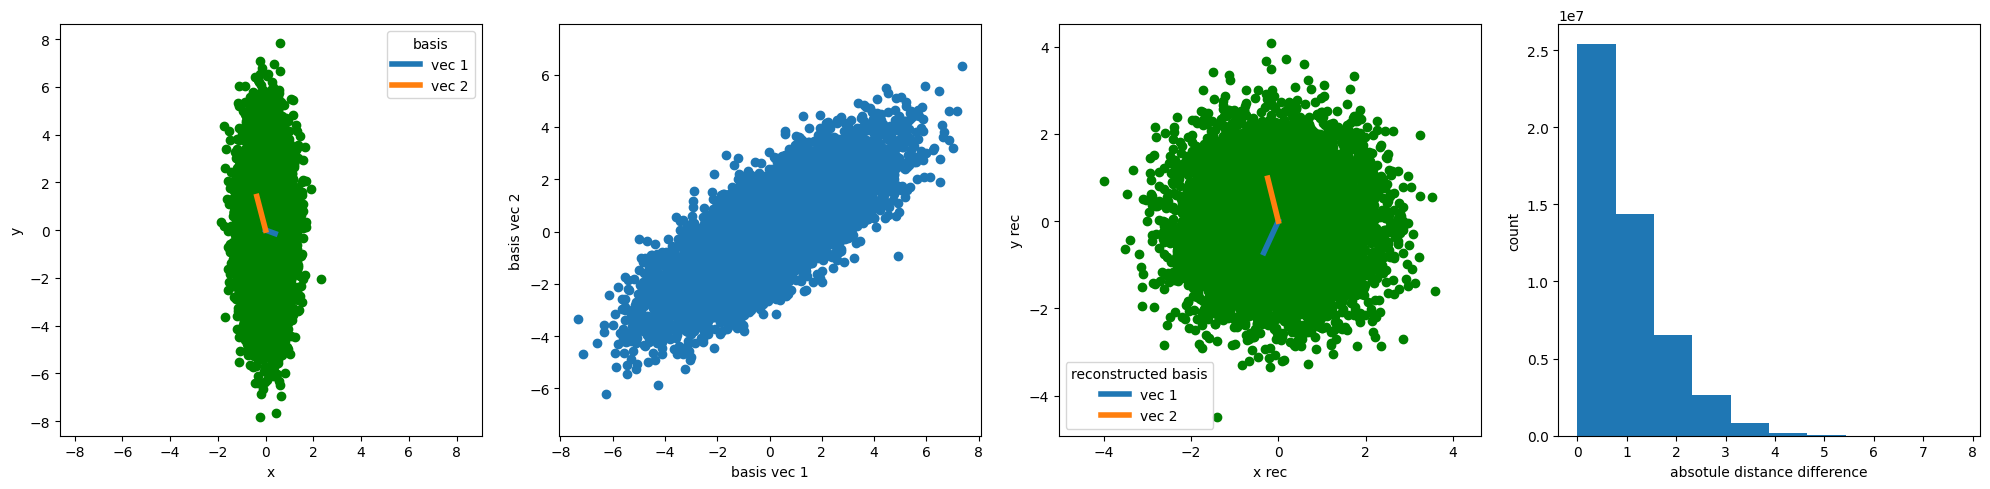

In [76]:
cov = [
    [0.25, 0], 
    [0, 4],
]
plot_recon(10000, cov=cov, fig_path='plots/basis_recon_isotropic.png')

Cov inv
[[ 12.49041778  -0.2387112   -1.21782474  -0.19973535   0.75230964
   -0.4428414    0.75325214  -1.19213255   5.83537836  -8.35759067
   -1.24528899  -0.39411958   5.65306706   0.33740285  -3.57701402
    3.31512416]
 [ -0.2387112   28.66818708  10.09395513  -4.80609564   0.69090304
   -3.70277435   2.125921     1.23252831   8.00710784  -0.90154272
    2.196665    -9.72558792  -3.26710348  -3.4252089    3.60844991
   -4.681341  ]
 [ -1.21782474  10.09395513  22.40801461  -7.06392798  -3.07741783
   -0.08149141  -1.59218971   1.58006038  -1.24627618   1.23837542
   -1.03011749  -6.53694548   2.19391444   0.54063843  -0.63393027
   -1.1431571 ]
 [ -0.19973535  -4.80609564  -7.06392798  17.97259005  -2.9410478
    5.48031167  -2.7734149   -0.19998245  -8.85930748  -0.09180531
    7.16679959   6.96652153  -0.47538814   5.53920393  -0.78707074
    0.19317211]
 [  0.75230964   0.69090304  -3.07741783  -2.9410478   18.43419266
   -1.95545528   4.59284434  -5.43946405   4.97348255  -6.

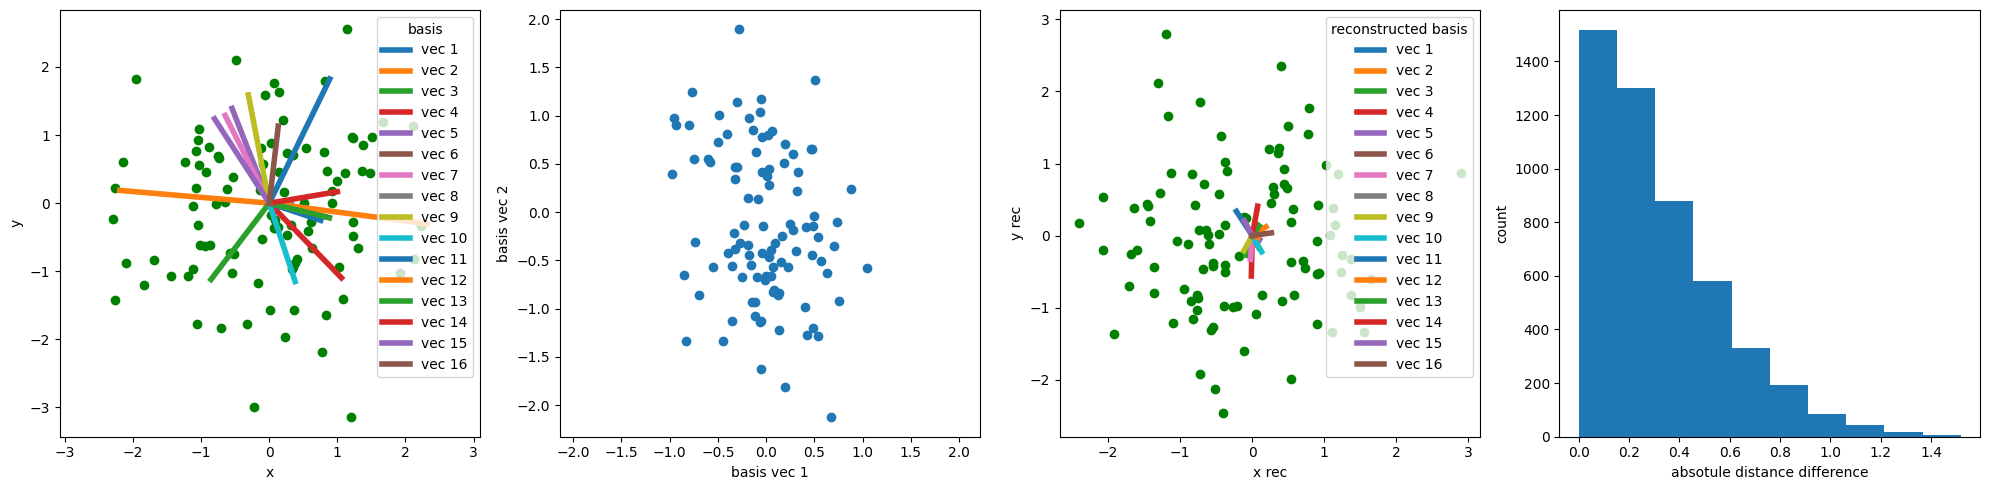

In [87]:
plot_recon(n=100, d=16)